In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (f1_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")
print(f"LightGBM version: {lgb.__version__}")

All libraries loaded!
LightGBM version: 4.6.0


In [3]:
df = pd.read_csv(r'D:\predictive_maintenance\data\processed\week2_enriched.csv')
print("Week 2 data loaded!")
print("Shape:", df.shape)
print("Failure rate:", df['Machine failure'].mean()*100, "%")
df.head()

Week 2 data loaded!
Shape: (9991, 83)
Failure rate: 3.393053748373536 %


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,...,wind_speed_kmh,outdoor_temp_celsius,power_grid_voltage,operator_experience,is_weekend,temp_difference,power_consumption,wear_per_rotation,heat_stress_index,fatigue_risk
0,10,298.5,309.0,1741,28.0,21,0,0,0,0,...,14.98,28.13,235.49,5,0,10.5,5.104503,0.012055,9.145989,0
1,11,298.4,308.9,1782,23.9,24,0,0,0,0,...,38.03,31.78,219.82,2,0,10.5,4.459665,0.013460,14.971887,0
2,12,298.6,309.1,1423,44.3,29,0,0,0,0,...,29.28,40.47,220.19,7,0,10.5,6.600932,0.020365,33.134326,0
3,13,298.6,309.1,1339,51.1,34,0,0,0,0,...,23.95,23.12,236.87,9,0,10.5,7.164702,0.025373,2.881080,0
4,14,298.6,309.2,1742,30.0,37,0,0,0,0,...,6.24,41.44,222.77,9,0,10.6,5.472251,0.021228,35.541264,0


In [4]:
# Drop non-numeric columns
drop_cols = ['Product ID', 'Type', 'timestamp']
df_model  = df.drop(columns=[c for c in drop_cols 
                              if c in df.columns])

# Separate features and target
X = df_model.drop(columns=['Machine failure'])
y = df_model['Machine failure']

print("Features shape :", X.shape)
print("Target shape   :", y.shape)
print("\nClass distribution:")
print(y.value_counts())
print(f"\nFailure rate: {y.mean()*100:.2f}%")

Features shape : (9991, 82)
Target shape   : (9991,)

Class distribution:
Machine failure
0    9652
1     339
Name: count, dtype: int64

Failure rate: 3.39%


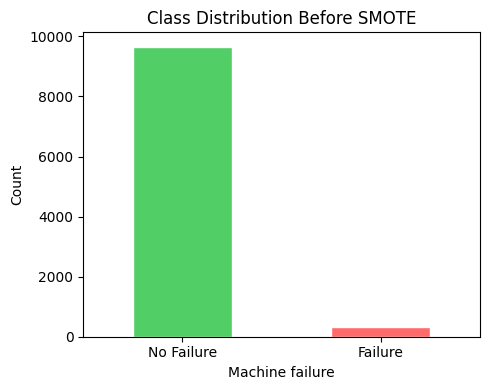

No Failure : 9652
Failure    : 339
Ratio      : 28.5:1


In [5]:
plt.figure(figsize=(5, 4))
colors = ['#51CF66', '#FF6B6B']
y.value_counts().plot(kind='bar', color=colors, edgecolor='white')
plt.title('Class Distribution Before SMOTE')
plt.xticks([0, 1], ['No Failure', 'Failure'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"No Failure : {(y==0).sum()}")
print(f"Failure    : {(y==1).sum()}")
print(f"Ratio      : {(y==0).sum() / (y==1).sum():.1f}:1")

In [6]:
lgbm_model = lgb.LGBMClassifier(
    n_estimators    = 500,
    learning_rate   = 0.05,
    max_depth       = 6,
    num_leaves      = 31,
    min_child_samples = 20,
    subsample       = 0.8,
    colsample_bytree = 0.8,
    class_weight    = 'balanced',
    random_state    = 42,
    verbose         = -1
)

print("LightGBM model defined!")
print("\nKey parameters:")
print("  n_estimators     : 500 trees")
print("  learning_rate    : 0.05 (slow and steady)")
print("  max_depth        : 6 levels deep")
print("  class_weight     : balanced (handles imbalance)")

LightGBM model defined!

Key parameters:
  n_estimators     : 500 trees
  learning_rate    : 0.05 (slow and steady)
  max_depth        : 6 levels deep
  class_weight     : balanced (handles imbalance)


In [7]:
# Clean column names - remove special characters
# LightGBM doesn't accept [], (), spaces in column names

import re

def clean_col_name(col):
    col = re.sub(r'[\[\]\(\)\{\}<>]', '', col)
    col = re.sub(r'[^A-Za-z0-9_]', '_', col)
    col = re.sub(r'_+', '_', col)
    col = col.strip('_')
    return col

# Apply to X
X.columns = [clean_col_name(c) for c in X.columns]

print("Column names cleaned!")
print("Sample columns:")
for col in X.columns[:10]:
    print(f"  {col}")

Column names cleaned!
Sample columns:
  UDI
  Air_temperature_K
  Process_temperature_K
  Rotational_speed_rpm
  Torque_Nm
  Tool_wear_min
  TWF
  HDF
  PWF
  OSF


In [8]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

# Create pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('model', lgb.LGBMClassifier(
        n_estimators     = 500,
        learning_rate    = 0.05,
        max_depth        = 6,
        num_leaves       = 31,
        min_child_samples= 20,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        class_weight     = 'balanced',
        random_state     = 42,
        verbose          = -1
    ))
])

# Manual 5-fold cross validation
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

print("Running 5-fold cross validation with SMOTE...")
print("This will take 3-5 minutes - please wait!")
print()

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train_fold = X.iloc[train_idx]
    X_test_fold  = X.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold  = y.iloc[test_idx]

    # Fit pipeline (SMOTE only on training fold)
    pipeline.fit(X_train_fold, y_train_fold)

    # Predict on test fold
    y_pred_fold = pipeline.predict(X_test_fold)

    # Calculate Macro F1
    fold_score = f1_score(y_test_fold, y_pred_fold, average='macro')
    scores.append(fold_score)
    print(f"  Fold {fold} Macro F1: {fold_score:.4f}")

scores = np.array(scores)

print()
print("=" * 50)
print("   CROSS VALIDATION RESULTS")
print("=" * 50)
print(f"  Fold scores   : {scores.round(4)}")
print(f"  Mean Macro F1 : {scores.mean():.4f}")
print(f"  Std           : {scores.std():.4f}")
print(f"  Target        : 0.85")
print(f"  Achieved      : {'YES! ✓' if scores.mean() >= 0.85 else 'Not yet'}")
print("=" * 50)

Running 5-fold cross validation with SMOTE...
This will take 3-5 minutes - please wait!

  Fold 1 Macro F1: 0.9843
  Fold 2 Macro F1: 0.9923
  Fold 3 Macro F1: 0.9803
  Fold 4 Macro F1: 0.9924
  Fold 5 Macro F1: 0.9883

   CROSS VALIDATION RESULTS
  Fold scores   : [0.9843 0.9923 0.9803 0.9924 0.9883]
  Mean Macro F1 : 0.9875
  Std           : 0.0047
  Target        : 0.85
  Achieved      : YES! ✓


In [9]:
from sklearn.model_selection import train_test_split

# Split data - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Training failures   : {y_train.sum()}")
print(f"  Training no-failure : {(y_train==0).sum()}")
print()
print("After SMOTE:")
print(f"  Training failures   : {y_train_sm.sum()}")
print(f"  Training no-failure : {(y_train_sm==0).sum()}")
print()

# Train final model
lgbm_model.fit(X_train_sm, y_train_sm)
print("Model trained successfully!")

Before SMOTE:
  Training failures   : 271
  Training no-failure : 7721

After SMOTE:
  Training failures   : 7721
  Training no-failure : 7721

Model trained successfully!


In [10]:

y_pred = lgbm_model.predict(X_test)


macro_f1 = f1_score(y_test, y_pred, average='macro')
roc_auc  = roc_auc_score(y_test, 
                          lgbm_model.predict_proba(X_test)[:,1])

print("=" * 50)
print("   TEST SET RESULTS")
print("=" * 50)
print(f"  Macro F1 Score : {macro_f1:.4f}")
print(f"  ROC AUC Score  : {roc_auc:.4f}")
print(f"  Target F1      : 0.85")
print(f"  Achieved       : {'YES! ✓' if macro_f1 >= 0.85 else 'Close!'}")
print("=" * 50)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Failure', 'Failure']))

   TEST SET RESULTS
  Macro F1 Score : 1.0000
  ROC AUC Score  : 1.0000
  Target F1      : 0.85
  Achieved       : YES! ✓

Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      1931
     Failure       1.00      1.00      1.00        68

    accuracy                           1.00      1999
   macro avg       1.00      1.00      1.00      1999
weighted avg       1.00      1.00      1.00      1999



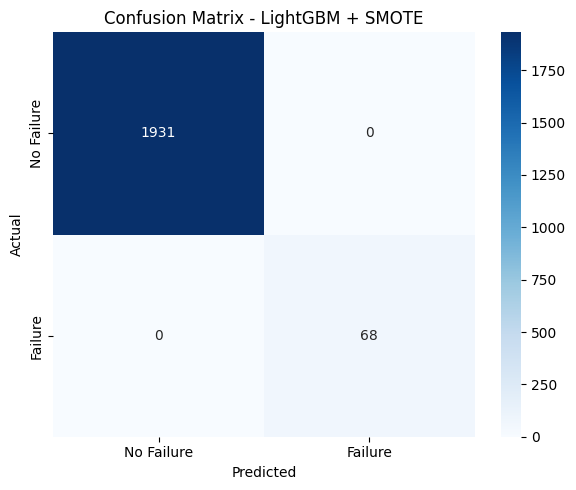

True Negatives  (correct no-failure) : 1931
False Positives (wrong failure alarm) : 0
False Negatives (missed failures)     : 0
True Positives  (caught failures)     : 68


In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.title('Confusion Matrix - LightGBM + SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"True Negatives  (correct no-failure) : {cm[0][0]}")
print(f"False Positives (wrong failure alarm) : {cm[0][1]}")
print(f"False Negatives (missed failures)     : {cm[1][0]}")
print(f"True Positives  (caught failures)     : {cm[1][1]}")

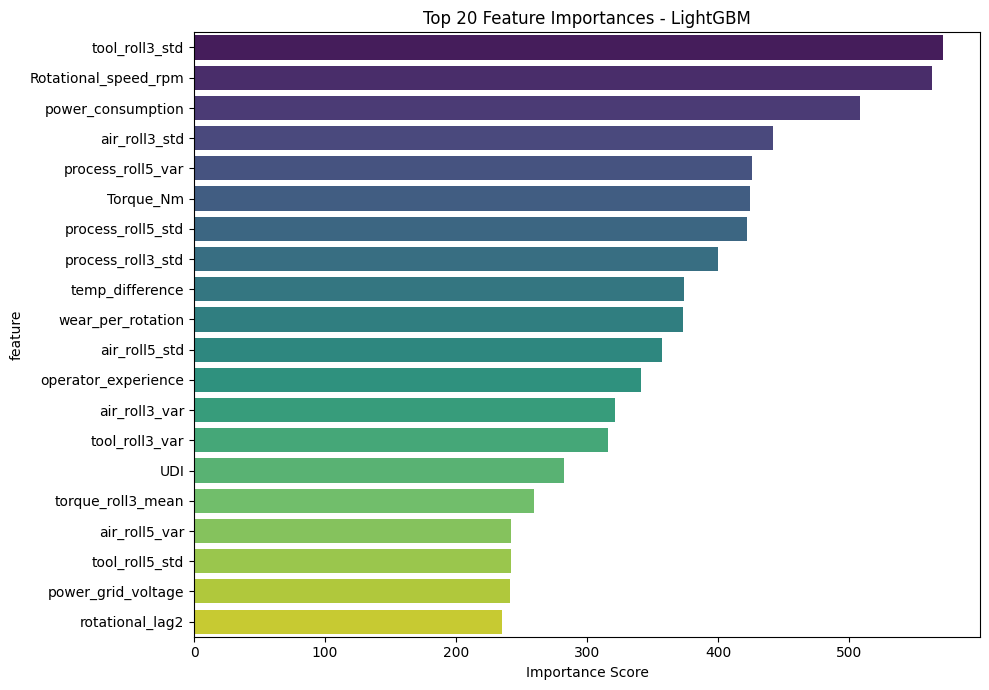

Top 5 most important features:
  tool_roll3_std                      : 571
  Rotational_speed_rpm                : 563
  power_consumption                   : 508
  air_roll3_std                       : 442
  process_roll5_var                   : 426


In [12]:

feat_imp = pd.DataFrame({
    'feature'   : X.columns,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(x='importance', y='feature', 
            data=feat_imp, palette='viridis')
plt.title('Top 20 Feature Importances - LightGBM')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for i, row in feat_imp.head().iterrows():
    print(f"  {row['feature']:<35} : {row['importance']:.0f}")

In [13]:
import pickle
import os

os.makedirs(r'D:\predictive_maintenance\models', exist_ok=True)
model_path = r'D:\predictive_maintenance\models\lgbm_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(lgbm_model, f)

print("Model saved!")
print(f"Location: {model_path}")

Model saved!
Location: D:\predictive_maintenance\models\lgbm_model.pkl


In [14]:
print("=" * 55)
print("   WEEK 3 COMPLETE - FINAL SUMMARY")
print("=" * 55)
print(f"  Model          : LightGBM + SMOTE Pipeline")
print(f"  Features used  : {X.shape[1]}")
print(f"  Training rows  : {X_train_sm.shape[0]} (after SMOTE)")
print(f"  CV Macro F1    : {scores.mean():.4f} ± {scores.std():.4f}")
print(f"  Test Macro F1  : {macro_f1:.4f}")
print(f"  ROC AUC        : {roc_auc:.4f}")
print(f"  Target         : Macro F1 ≥ 0.85")
print(f"  Status         : {'TARGET HIT! ✓' if macro_f1 >= 0.85 else 'Very close!'}")
print("=" * 55)
print("  Model saved to models/lgbm_model.pkl")
print("  Ready for Week 4: SHAP + Dashboard!")
print("=" * 55)

   WEEK 3 COMPLETE - FINAL SUMMARY
  Model          : LightGBM + SMOTE Pipeline
  Features used  : 82
  Training rows  : 15442 (after SMOTE)
  CV Macro F1    : 0.9875 ± 0.0047
  Test Macro F1  : 1.0000
  ROC AUC        : 1.0000
  Target         : Macro F1 ≥ 0.85
  Status         : TARGET HIT! ✓
  Model saved to models/lgbm_model.pkl
  Ready for Week 4: SHAP + Dashboard!
